# 位置情報データチェックと気象データ取得準備
- トップリバーのデータ
- 作物はレタス（一部、白菜が入っている）

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import ast
import matplotlib.pyplot as plt

In [2]:
### 変数設定 ###
farm_dir = 'farm'
#--当初のデータ
farm_excel = '【Confidential】サンプルデータ（トップリバー様） (2).xlsx'
excel_sheet = 'トップリバー様（NDVI）'
# #--追加のデータ（通常のxlsxフォーマット変換後）
# farm_excel = '【Confidential】サンプルデータ_トップリバー様_251203.xlsx'
# excel_sheet = 'トップリバー様'
farm_file = 'topriver_farm.csv'
gpkg_file = 'topriver_farm.gpkg'
gpkg_layer = 'topriver_farm'

- 最新のデータには新規の圃場が含まれているため、旧データで採番したIDと一致しなくなってしまうことから、旧データを使うこととする
- 2025年の新規圃場は過去データもなく、気象データも取得していないため、解析対象外とする
- 本notebookは旧データで作成することとする。また本来は、システム側でユニークIDを割り振っておくことが望ましい
- 新データが『Strict Open XML スプレッドシート』フォーマットのため、もし読み込む場合は通常のExcel（xlsx）フォーマットに変換する必要あり

## 農場テーブル作成
- 圃場名とポリゴン情報は1対1に対応
- Excelファイルの「トップリバー様」と「トップリバー様（NDVI）」は圃場数が一致しない
    - 「トップリバー様（NDVI）」から農場テーブルを作成する

In [3]:
#--Excelファイル読み込み
df_org = pd.read_excel(f'{farm_dir}/{farm_excel}', sheet_name=excel_sheet)
df_org.dropna(inplace=True)
df_org.head()

,栽培グループ名,年度,圃場名,polygon,定植日,収穫日,経過日,NDVI値
0,【新】御代田地区：ウィザード,2018.0,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...",2018-03-02,2018-04-29,0.0,0.000000
1,【新】御代田地区：ウィザード,2018.0,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...",2018-03-02,2018-04-29,2.0,0.070096
2,【新】御代田地区：ウィザード,2018.0,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...",2018-03-02,2018-04-29,5.0,0.000000
3,【新】御代田地区：ウィザード,2018.0,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...",2018-03-02,2018-04-29,10.0,0.000000
4,【新】御代田地区：ウィザード,2018.0,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...",2018-03-02,2018-04-29,12.0,0.092308


In [4]:
#--圃場名とポリゴンがユニークか確認
print("圃場名とポリゴンで重複を削除", df_org.drop_duplicates(subset=['圃場名','polygon']).shape )
print("圃場名のユニーク数", len(df_org['圃場名'].unique()) )
print("ポリゴンのユニーク数", len(df_org['polygon'].unique()) )

圃場名とポリゴンで重複を削除 (230, 8)
圃場名のユニーク数 230
ポリゴンのユニーク数 230


In [5]:
#--農場データフレーム作成
colnames = ['栽培グループ名', '圃場名', 'polygon']
df_farm = df_org[colnames].drop_duplicates(subset=['圃場名','polygon']).reset_index(drop=True)
# df_farm.to_csv(f"{farm_dir}/{farm_file}", index=False)

In [ ]:
# def convert_to_polygon(geom_str):
#     coords_list = ast.literal_eval(geom_str)  # 文字列をリストに safely 変換
#     return Polygon(coords_list)  # 最外周の1つ目のリング（穴がなければこれだけでOK）

# # ast.literal_eval は安全に文字列 → Pythonリストに変換できます（evalは使わないでください）。
# # ポリゴンの穴（内側リング）がある場合は Polygon(outer_ring, [hole1, hole2, ...]) のように加工が必要です。

# df["geometry"] = df["polygon"].apply(convert_to_polygon)
# df.head()

In [6]:
#--ポリゴンのテキスト情報を地理情報フォーマットに変換
def make_polygon(geom_str):
    coords_latlon = ast.literal_eval(geom_str)
    #--lat,lon の順番を、lon,latに変える
    coords_lonlat = [(lon, lat) for lat, lon in coords_latlon]
    return Polygon(coords_lonlat)

df_farm["geometry"] = df_farm["polygon"].apply(make_polygon)
df_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,【新】御代田地区：ウィザード,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...","POLYGON ((138.4902147 36.2997065, 138.490014 3..."
1,【新】御代田地区：ウィザード,小川屋②,"[[36.299948, 138.492681], [36.2999137, 138.492...","POLYGON ((138.492681 36.299948, 138.4926023 36..."
2,【新】御代田地区：ウィザード,小川屋③,"[[36.300037, 138.490929], [36.3000488, 138.490...","POLYGON ((138.490929 36.300037, 138.4908376 36..."
3,【新】御代田地区：ウィザード,小川屋⑥,"[[36.298945, 138.489726], [36.298808, 138.4895...","POLYGON ((138.489726 36.298945, 138.489586 36...."
4,【新】御代田地区：ウィザード,小川屋⑤,"[[36.299423, 138.489992], [36.2992891, 138.489...","POLYGON ((138.489992 36.299423, 138.4899496 36..."


In [7]:
#--GeoDataFrameに変換
gdf_farm = gpd.GeoDataFrame(df_farm, geometry="geometry", crs="EPSG:4326")
gdf_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,【新】御代田地区：ウィザード,小川屋④,"[[36.2997065, 138.4902147], [36.299465, 138.49...","POLYGON ((138.49021 36.29971, 138.49001 36.299..."
1,【新】御代田地区：ウィザード,小川屋②,"[[36.299948, 138.492681], [36.2999137, 138.492...","POLYGON ((138.49268 36.29995, 138.4926 36.2999..."
2,【新】御代田地区：ウィザード,小川屋③,"[[36.300037, 138.490929], [36.3000488, 138.490...","POLYGON ((138.49093 36.30004, 138.49084 36.300..."
3,【新】御代田地区：ウィザード,小川屋⑥,"[[36.298945, 138.489726], [36.298808, 138.4895...","POLYGON ((138.48973 36.29894, 138.48959 36.298..."
4,【新】御代田地区：ウィザード,小川屋⑤,"[[36.299423, 138.489992], [36.2992891, 138.489...","POLYGON ((138.48999 36.29942, 138.48995 36.299..."


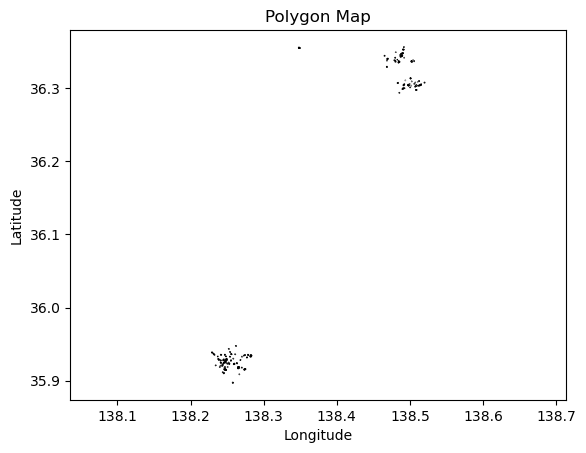

In [8]:
#--可視化を試す
gdf_farm.plot(edgecolor='black', facecolor='lightblue')
plt.title("Polygon Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal') # スケールを揃える
plt.show()

In [ ]:
#--GeoPackage形式で出力
# gdf_farm.to_file(f"{farm_dir}/{gpkg_file}", driver='GPKG', layer=gpkg_layer, encoding='utf-8')

In [9]:
#--各ポリゴンの重心位置を計算
latitude = []
longitude = []
for i, row in gdf_farm.iterrows():
    center = list(row['geometry'].centroid.coords)[0]
    longitude.append(center[0])
    latitude.append(center[1])

gdf_farm["longitude"] = longitude
gdf_farm["latitude"] = latitude

In [10]:
#--便宜上、圃場ごとの固有IDをつける
gdf_farm['field_id'] = ["topriver" + str(i).zfill(3) for i in range(len(gdf_farm))]

#--緯度経度情報を含めてCSV出力
col_order = ['field_id', '栽培グループ名', '圃場名', 'longitude', 'latitude', 'polygon']
gdf_farm[col_order].to_csv(f"{farm_dir}/{farm_file}", index=False)